# Model 2: Logistic Regression

In [46]:
# Libraries
library(tidyverse)
library(infer)
library(cowplot)
library(broom)
library(GGally)
library(arm)

Loading required package: MASS

Attaching package: ‘MASS’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack

Loading required package: lme4

arm (Version 1.15-3, built: 2026-4-15)

Working directory is c:/Users/leoni/Documents/GitHub/stat-301-project



Warning messages:
1: package ‘arm’ was built under R version 4.4.3 
2: package ‘lme4’ was built under R version 4.4.3 


In [55]:
# set your working directory properly to the folder containing the file
# you can use getwd() and setwd()
sample_df<- read_csv("data/chicago_walkability_sample.csv")
columns_df <- read_tsv("data/COLUMN_DESCRIPTORS.tsv")

# pick your variables

columns <- c(
  # Categorical Variables
  "is_most_walkable",
  # Numerical variables
  "walkability_index",
  "pop_density_per_sqmi",
  "median_household_income",
  "median_home_value"
)

sample_df <- sample_df %>%
  dplyr::select(all_of(columns)) %>%
  mutate(
    pop_density_per_sqmi = pop_density_per_sqmi/1000,
    median_household_income = median_household_income/1000,
    median_home_value = median_home_value/1000
  )




Rows: 6571 Columns: 48
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): tract_name, metro, state, safe_walk_tier, walkability_tier, income_source
dbl (38): geoid, walkability_index, walkability_pctile, county_ped_death_rate_per_100k, ped_safety_pctile, safe_walk_score, walk_s...
lgl  (4): is_most_walkable, is_affordable, is_walkable_affordable, is_commercial_desert

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 47 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): geoid, 12-digit Census block group GEOID (state+county+tract+block group). Read as text; join key to Census/ACS block gro...

ℹ Use `spec()` to retrieve the full column specification for

Warning messages:
1: Removed 583 rows containing non-finite outside the scale range (`stat_boxplot()`). 
2: Removed 458 rows containing non-finite outside the scale range (`stat_boxplot()`). 


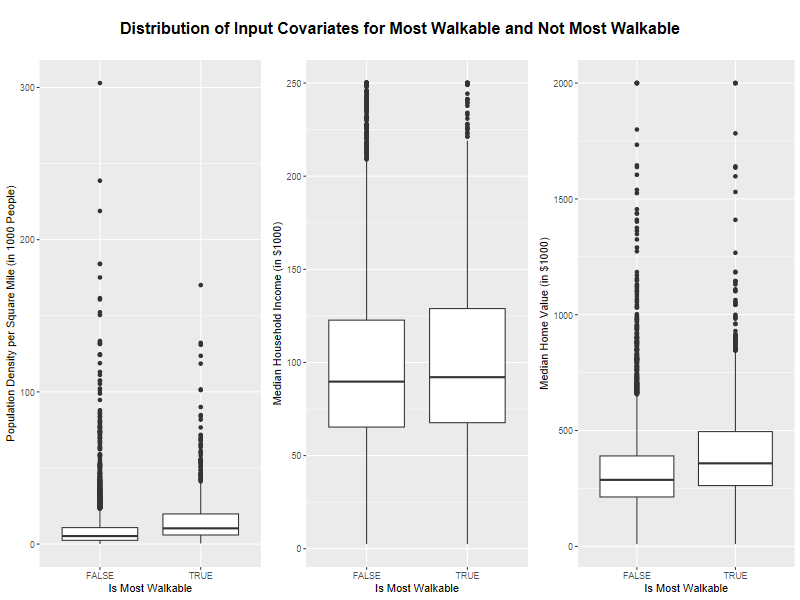

In [56]:
# visualization
density_boxplot <- sample_df %>%
  ggplot(aes(is_most_walkable, pop_density_per_sqmi)) +
  geom_boxplot() +
  xlab("Is Most Walkable") +
  ylab("Population Density per Square Mile (in 1000 People)")

income_boxplot <- sample_df %>%
  ggplot(aes(is_most_walkable, median_household_income)) +
  geom_boxplot() +
  xlab("Is Most Walkable") +
  ylab("Median Household Income (in $1000)")

value_boxplot <- sample_df %>%
  ggplot(aes(is_most_walkable, median_home_value)) +
  geom_boxplot() +
  xlab("Is Most Walkable") +
  ylab("Median Home Value (in $1000)")

title <- ggdraw() +
  draw_label(
    "Distribution of Input Covariates for Most Walkable and Not Most Walkable",
    fontface = 'bold',
    size = 16,
    x = 0.5,
    hjust = 0.5
  )


boxplots <- plot_grid(
  plotlist = c(density_boxplot, income_boxplot, value_boxplot),
  nrow = 1,
  ncol = 3
)

boxplots_with_title <- plot_grid(
  title, boxplots,
  nrow = 2,
  rel_heights = c(0.1, 1)
)
print(boxplots_with_title)

In [57]:
# model & estimates
logit_model <- glm(is_most_walkable ~ 
  pop_density_per_sqmi +
  median_household_income +
  median_home_value, 
  data = sample_df, 
  family = binomial
)
logit_model_summary <- logit_model %>%
  tidy()
print(logit_model_summary)

# A tibble: 4 × 5
  term                    estimate std.error statistic   p.value
  <chr>                      <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)             -1.94     0.0871      -22.3  4.99e-110
2 pop_density_per_sqmi     0.0251   0.00261       9.62 6.86e- 22
3 median_household_income -0.00719  0.000973     -7.38 1.54e- 13
4 median_home_value        0.00297  0.000230     12.9  4.23e- 38


NULL


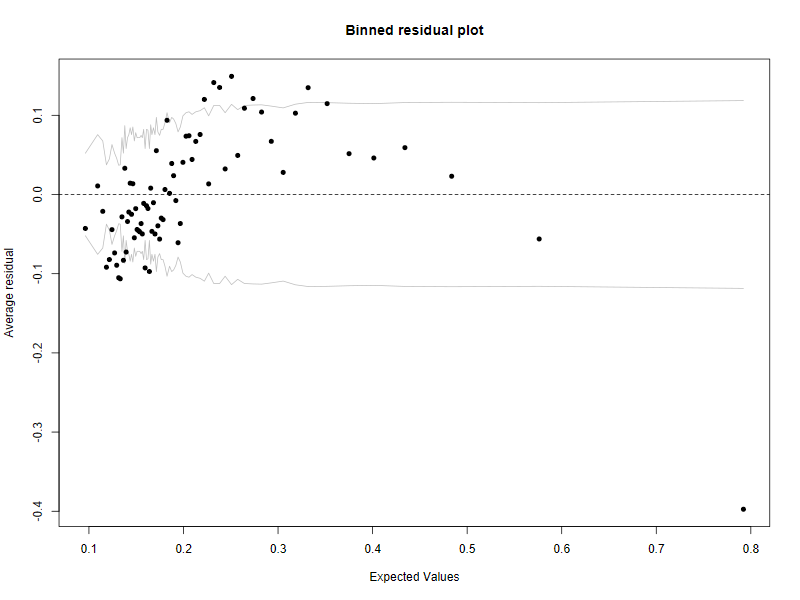

In [58]:
# Diagnostics
residuals <- logit_model %>%
  augment() %>%
  mutate(
    pred_prob = logit_model$fitted,
    resid_raw = residuals(logit_model, type = "response")
  )
resid <- residuals$resid_raw
fit <- residuals$pred_prob
binnedplot <- binnedplot(fit, resid)
print(binnedplot)


